# STAC-GP building blocks: OLCP vs. OS-GP-CP on a shared static GP

This notebook **combines the OLCP calibration layer with the OS-GP-CP (static and varying)
calibration layers**, all wrapped around a single *static, frozen* Gaussian-process width model,
following the setup in the thesis *"Calibrated uncertainty in Gaussian Process models using
Online Localised Conformal Prediction"* (STAC-GP).

The idea (thesis §4): the point forecast of the move is taken to be zero (martingale), so all
the modelling lives in the **half-width**. A start-of-day volatility prior $w^{\text{prior}}_t$ is
rescaled by a positive, GP-driven multiplicative factor $g(x_t)=\exp(f(x_t))$ to give a width
$w^{\text{GP}}_t = g(x_t)\,w^{\text{prior}}_t$. The GP is fit once on history and frozen. A conformal
layer then calibrates the width online.

We compare three conformal layers on the **identical frozen width**:

| Layer | Threshold | Adaptive over time | Localised in covariate space |
|---|---|---|---|
| **OS-GP-CP (static $\eta=0.05$)** | global, NLL-inverted | yes (fixed step) | no |
| **OS-GP-CP (varying $\eta_t$)** | global, NLL-inverted | yes (decaying + resets) | no |
| **OLCP (localised + adaptive)** | localised weighted quantile | yes ($\alpha_t$ feedback) | **yes** |

Because every layer wraps the same GP width, any difference in coverage/width is due purely to the
calibration layer — exactly the baseline comparison in the thesis (OS-GP-CP is global-adaptive;
OLCP adds covariate localisation).

## 0. Imports and project layout

`online_conformal` (OS-GP-CP) is loaded from the `GPCP` module; the OLCP machinery
(`eval_olcp`, localised weighted quantile) from `OLCP/cp_methods.py`. We locate the repo root
automatically by finding the folder that contains both `OLCP/` and `GPCP/`.

In [1]:
import warnings; warnings.filterwarnings("ignore")
import sys, importlib.util
from pathlib import Path
import numpy as np, pandas as pd
import matplotlib.pyplot as plt

from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel, WhiteKernel

def find_root(start=None):
    p = Path(start or Path.cwd()).resolve()
    for cand in [p, *p.parents]:
        if (cand / "OLCP").is_dir() and (cand / "GPCP").is_dir():
            return cand
    raise FileNotFoundError("Could not find a folder containing both OLCP/ and GPCP/. "
                            "Run this notebook from inside the Thesis folder.")

ROOT = find_root()
print("project root:", ROOT)

# OLCP conformal methods
sys.path.insert(0, str(ROOT / "OLCP"))
import cp_methods as cpm

# OS-GP-CP: online_conformal from the GPCP module (filename has a space)
gp_path = ROOT / "GPCP" / "Ensemble Guassian Process.py"
spec = importlib.util.spec_from_file_location("gpmod", gp_path)
gpmod = importlib.util.module_from_spec(spec); spec.loader.exec_module(gpmod)
online_conformal = gpmod.online_conformal
print("loaded:", cpm.__name__, "+", gpmod.__file__.split('/')[-1])

project root: /mnt/c/Users/Maxim/Documents/Thesis
loaded: cp_methods + Ensemble Guassian Process.py


## 1. Configuration

`ETF` picks the price series from `OLCP/data/`. `ALPHA` is the target miscoverage (0.1 → 90%
coverage). `N_TRAIN` is the history used to fit-and-freeze the GP; everything after is the online
test stream. `R` is the conformal calibration window.

In [2]:
ETF      = "spy"      # spy | qqq | iwm | eem | tlt
ALPHA    = 0.10       # target miscoverage -> 1-ALPHA = 0.90 coverage
N_TRAIN  = 500        # history for the static GP fit (then frozen)
R        = 200        # conformal calibration window (past scores)
VOL_WIN  = 20         # trailing window for the start-of-day vol prior
H        = 1.0        # forecast horizon (1 step); w_prior = sigma0 * sqrt(H)
ETA_STATIC = 0.05     # OS-GP-CP constant step size (thesis / Xu et al.)

## 2. Data and the multiplicative-width model (thesis §4.1)

We take the response $Y_t$ to be the close-to-close price change and set $\hat Y_t = 0$
(martingale). The start-of-day prior is a causal trailing volatility,
$w^{\text{prior}}_t = \sigma_{0,t}\sqrt{H}$ with $\sigma_{0,t}$ the trailing std of $Y$.

The **GP features** $x_t$ are causal vol-state proxies (all lagged, so nothing peeks at $Y_t$):
log trailing vol, average high–low range, recent $|Y|$, and log volume. These also serve as the
**localiser covariates** for OLCP.

In [3]:
csv = ROOT / "OLCP" / "data" / f"{ETF}_us_d.csv"
df = pd.read_csv(csv, parse_dates=["Date"]).sort_values("Date").reset_index(drop=True)
close = df["Close"].to_numpy(float)
high  = df["High"].to_numpy(float)
low   = df["Low"].to_numpy(float)
vol   = df["Volume"].to_numpy(float)
dates = df["Date"].to_numpy()

Y    = np.diff(close, prepend=close[0])                 # close-to-close change; Yhat = 0
absY = np.abs(Y)

# start-of-day volatility prior (causal: shift(1) before rolling)
sigma0  = pd.Series(Y).shift(1).rolling(VOL_WIN).std().to_numpy()
w_prior = sigma0 * np.sqrt(H)

# causal vol-state features (drive the GP width AND localise the OLCP threshold)
rng_hl = (high - low) / close
feat = np.column_stack([
    np.log(np.clip(w_prior, 1e-8, None)),                            # log trailing vol
    pd.Series(rng_hl).shift(1).rolling(10).mean().to_numpy(),        # avg high-low range
    pd.Series(absY).shift(1).rolling(5).mean().to_numpy(),           # recent |Y|
    pd.Series(np.log(np.clip(vol, 1, None))).shift(1).rolling(10).mean().to_numpy(),  # log volume
])
feat_names = ["log_vol", "hl_range", "recent_absY", "log_volume"]

# drop warm-up rows that still contain NaNs
ok = np.isfinite(feat).all(1) & np.isfinite(w_prior) & (w_prior > 0)
Y, absY, w_prior, feat, dates = Y[ok], absY[ok], w_prior[ok], feat[ok], dates[ok]
T = len(Y)
print(f"{ETF.upper()}  usable days: {T}   ({str(dates[0])[:10]} -> {str(dates[-1])[:10]})")
print(f"train: first {N_TRAIN}   |   online test: {T - N_TRAIN}")

SPY  usable days: 5310   (2005-03-28 -> 2026-05-05)
train: first 500   |   online test: 4810


## 3. Static GP fit, then freeze (thesis §4.1)

The GP target is the **log realised-volatility residual** $z_t=\log(|Y_t|/w^{\text{prior}}_t)$.
We fit an RBF (ARD) + White-noise GP once on the first `N_TRAIN` points, freeze the posterior mean
$f$, and form the frozen width $w^{\text{GP}}_t=\exp(f(x_t))\,w^{\text{prior}}_t$ for the whole
series. The scale-free nonconformity score (thesis §4.2) is $S_t=|Y_t|/w^{\text{GP}}_t$.

In [4]:
z = np.log(np.clip(absY, 1e-8, None) / w_prior)          # log-vol residual target

# standardise features within the TRAIN window only (causal)
mx, sx = feat[:N_TRAIN].mean(0), feat[:N_TRAIN].std(0) + 1e-12
F = (feat - mx) / sx

kernel = (ConstantKernel(1.0, (1e-2, 1e2))
          * RBF(np.ones(feat.shape[1]), (1e-1, 1e2))
          + WhiteKernel(0.5, (1e-3, 1e1)))
gpr = GaussianProcessRegressor(kernel=kernel, alpha=0.0,
                               n_restarts_optimizer=2, normalize_y=True)
gpr.fit(F[:N_TRAIN], z[:N_TRAIN])                         # <-- fit once
print("fitted kernel:", gpr.kernel_)

f_hat = gpr.predict(F)                                    # frozen posterior mean, all t
w_GP  = np.exp(np.clip(f_hat, -3.0, 3.0)) * w_prior       # GP-driven half-width
S     = absY / w_GP                                       # scale-free score
print(f"w_GP percentiles [5,50,95]: {np.round(np.percentile(w_GP,[5,50,95]),3)}")
print(f"median score S: {np.median(S):.3f}  (a well-fit width sits near the 1-alpha quantile)")

fitted kernel: 0.264**2 * RBF(length_scale=[0.357, 66.5, 0.1, 1.08]) + WhiteKernel(noise_level=0.93)
w_GP percentiles [5,50,95]: [0.257 0.662 2.989]
median score S: 1.260  (a well-fit width sits near the 1-alpha quantile)


## 4. OS-GP-CP layers — global adaptive threshold (static & varying)

OS-GP-CP calibrates with a **single global threshold** updated by feedback, using the Gaussian-NLL
score and an NLL-inverted interval. We give it the *same* GP width by treating the predictive law
as $p(Y_t)=\mathcal N(0,\,(w^{\text{GP}}_t)^2)$ — i.e. mean $\hat Y_t=0$, variance
$(w^{\text{GP}}_t)^2$ — and call the GPCP `online_conformal` with `step=0.05` (static) and
`step="varying"` (decaying $\eta_t=t^{-3/5}$ with change-point resets, window $W=15$, $r=100$).

In [5]:
is_test   = np.arange(T) >= N_TRAIN
test_idx  = np.where(is_test)[0]
mu0       = np.zeros(T)                     # martingale point forecast
var_GP    = w_GP ** 2                       # GP width as predictive variance

cp_static = online_conformal(Y[test_idx], mu0[test_idx], var_GP[test_idx],
                             alpha=ALPHA, step=ETA_STATIC)
cp_vary   = online_conformal(Y[test_idx], mu0[test_idx], var_GP[test_idx],
                             alpha=ALPHA, step="varying", c=1.0, eps=0.1, W=15, r=100)
print(f"OS-GP-CP static  : raw coverage {cp_static['covered'].mean():.3f}")
print(f"OS-GP-CP varying : raw coverage {cp_vary['covered'].mean():.3f}  |  resets: {len(cp_vary['resets'])}")

OS-GP-CP static  : raw coverage 0.876
OS-GP-CP varying : raw coverage 0.855  |  resets: 0


## 5. OLCP layer — localised + adaptive threshold (thesis §4.3)

OLCP uses a covariate-localised weighted quantile of past scores with an online $\alpha_t$ update.
We call the repo's own `cp_methods.eval_olcp` with a small, exact trick that turns its additive
interval into the thesis's multiplicative-width band:

- feed `y = score = S_t` and `pred = 0`. The returned `upper` column is then exactly the localised
  multiplier $q_t(x_t)$, and its `covered` column ($S_t \le q_t$) is *exactly* the real coverage
  event $|Y_t| \le q_t\,w^{\text{GP}}_t$.
- reconstruct the real band half-width as $q_t\,w^{\text{GP}}_t$ and width $=2q_t w^{\text{GP}}_t$.

The localiser uses the same vol-state features as covariates, so the threshold adapts by regime.

In [6]:
data = [{
    "series_id": 0,
    "y":     S,                 # feeding the score as 'y' => covered col is the true event
    "pred":  np.zeros(T),       # => returned 'upper' equals the localised multiplier q_t
    "score": S,
    "X":     feat,              # localiser covariates (vol-state)
    "is_test": is_test,
    "const_test": False,
}]
df_olcp, _ = cpm.eval_olcp(data, alpha=ALPHA, R=R, show_pbar=False)

t_olcp    = df_olcp["t"].to_numpy()
q_olcp    = df_olcp["upper"].to_numpy()             # localised multiplier q_t(x_t)
cov_olcp  = df_olcp["covered"].to_numpy()           # |Y_t| <= q_t * w_GP_t  (exact)
wid_olcp  = 2.0 * q_olcp * w_GP[t_olcp]             # real band width in price units
print(f"OLCP raw coverage {cov_olcp.mean():.3f}  |  bandwidth h0 = {df_olcp['h0'].iloc[0]:.3f}")

OLCP done in 0.97s | rows=4809
OLCP raw coverage 0.899  |  bandwidth h0 = 0.980


## 6. Comparison

We line the three layers up on a common evaluation window (test points with a full calibration
history, $t \ge$ `N_TRAIN + R`) and report empirical coverage vs. the 0.90 target and average band
width (price units, directly comparable since every layer wraps the same width).

In [7]:
EVAL_START = N_TRAIN + R

def to_series(t_arr, cov, wid):
    return pd.DataFrame({"t": t_arr, "covered": cov, "width": wid}).set_index("t")

results = {
    "OS-GP-CP (static η=0.05)": to_series(test_idx, cp_static["covered"], cp_static["size"]),
    "OS-GP-CP (varying η_t)":  to_series(test_idx, cp_vary["covered"],   cp_vary["size"]),
    "OLCP (localised+adaptive)": to_series(t_olcp, cov_olcp, wid_olcp),
}

rows = []
for name, s in results.items():
    s = s[s.index >= EVAL_START]
    w = s["width"].replace([np.inf, -np.inf], np.nan)
    rows.append({"Method": name,
                 "Coverage": s["covered"].mean(),
                 "Target": 1 - ALPHA,
                 "|cov-target|": abs(s["covered"].mean() - (1 - ALPHA)),
                 "Avg width": w.mean(),
                 "Width vol": w.diff().abs().mean(),   # jumpiness of the band
                 "N": int(len(s))})
summary = pd.DataFrame(rows)
summary.style.format({"Coverage":"{:.3f}","Target":"{:.2f}","|cov-target|":"{:.3f}",
                       "Avg width":"{:.3f}","Width vol":"{:.3f}"}) \
    if False else print(summary.to_string(index=False,
        formatters={"Coverage":"{:.3f}".format,"Target":"{:.2f}".format,
                    "|cov-target|":"{:.3f}".format,"Avg width":"{:.3f}".format,
                    "Width vol":"{:.3f}".format}))

                   Method Coverage Target |cov-target| Avg width Width vol    N
 OS-GP-CP (static η=0.05)    0.882   0.90        0.018     8.107     0.321 4610
   OS-GP-CP (varying η_t)    0.858   0.90        0.042     7.387     0.286 4610
OLCP (localised+adaptive)    0.900   0.90        0.000     8.940     0.723 4610


### 6.1 Rolling coverage and band width over the online stream

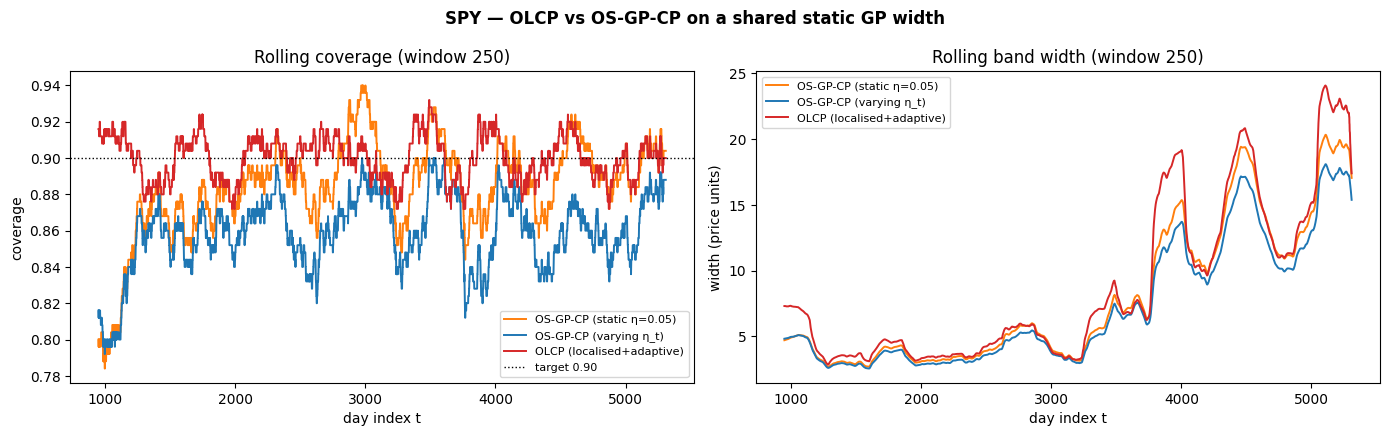

In [8]:
def rolling(a, w=250):
    a = np.asarray(a, float)
    return a if len(a) < w else np.convolve(a, np.ones(w)/w, mode="valid")

# common index across methods on the eval window
common = None
for s in results.values():
    idx = s.index[s.index >= EVAL_START]
    common = idx if common is None else common.intersection(idx)
common = common.sort_values()

colors = {"OS-GP-CP (static η=0.05)": "C1",
          "OS-GP-CP (varying η_t)":  "C0",
          "OLCP (localised+adaptive)": "C3"}

fig, ax = plt.subplots(1, 2, figsize=(14, 4.4))
WIN = 250
for name, s in results.items():
    s = s.reindex(common)
    ax[0].plot(common[WIN-1:], rolling(s["covered"].to_numpy(), WIN), color=colors[name], lw=1.4, label=name)
    ax[1].plot(common[WIN-1:], rolling(s["width"].to_numpy(), WIN),   color=colors[name], lw=1.4, label=name)
ax[0].axhline(1-ALPHA, color="k", ls=":", lw=1, label=f"target {1-ALPHA:.2f}")
ax[0].set(title=f"Rolling coverage (window {WIN})", xlabel="day index t", ylabel="coverage")
ax[0].legend(fontsize=8)
ax[1].set(title=f"Rolling band width (window {WIN})", xlabel="day index t", ylabel="width (price units)")
ax[1].legend(fontsize=8)
fig.suptitle(f"{ETF.upper()} — OLCP vs OS-GP-CP on a shared static GP width", fontweight="bold")
plt.tight_layout(); plt.show()

### 6.2 Bands around price on a slice of the test stream

Reconstructing price bands from the width layers: $\text{price}_t \pm \tfrac12\,\text{width}_t$.

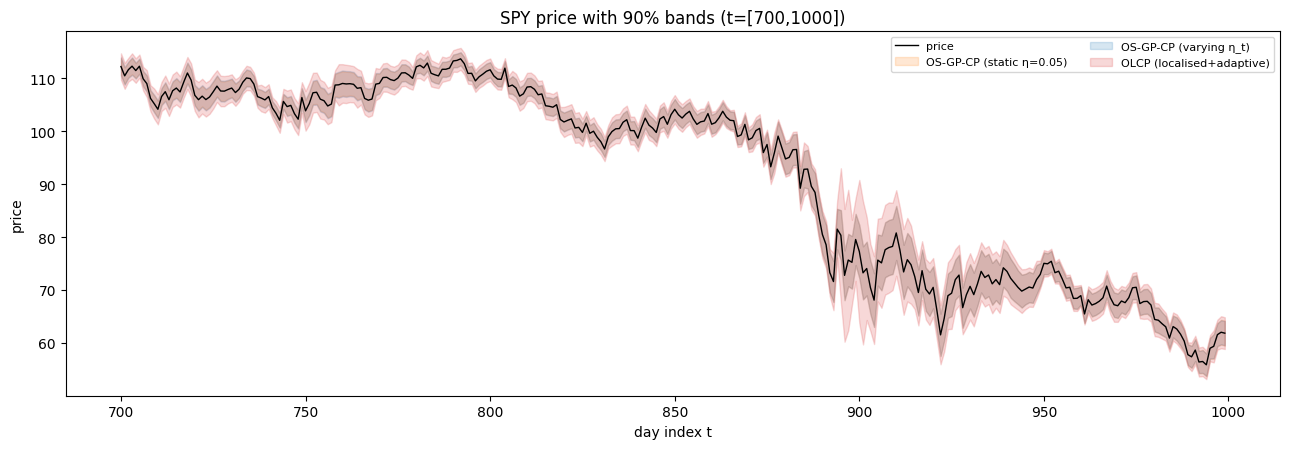

In [9]:
# rebuild a price path aligned to our (post-warmup) arrays and overlay the bands
price = np.cumsum(Y) + close[0]                # reconstructed close from changes
lo, hi = EVAL_START, min(EVAL_START + 300, T)  # a 300-day window
seg = np.arange(lo, hi)

fig, ax = plt.subplots(figsize=(13, 4.6))
ax.plot(seg, price[seg], "k-", lw=1.0, label="price")
for name, s in results.items():
    s = s.reindex(seg)
    half = s["width"].to_numpy() / 2.0
    ax.fill_between(seg, price[seg]-half, price[seg]+half, alpha=0.18, color=colors[name], label=name)
ax.set(title=f"{ETF.upper()} price with {int((1-ALPHA)*100)}% bands (t=[{lo},{hi}])",
       xlabel="day index t", ylabel="price")
ax.legend(fontsize=8, ncol=2); plt.tight_layout(); plt.show()

## 7. Notes

- **Fair comparison.** All three layers wrap the *same frozen* $w^{\text{GP}}$; the only difference
  is the conformal threshold. OS-GP-CP applies one global, time-adaptive threshold; OLCP applies a
  covariate-localised, time-adaptive threshold. This isolates the effect of localisation — the
  thesis's central claim.
- **OS-GP-CP mapping.** Feeding mean $0$ and variance $(w^{\text{GP}})^2$ makes the GPCP NLL score
  a monotone function of $|Y_t|/w^{\text{GP}}_t$, so both families calibrate the same underlying
  quantity and their widths are directly comparable.
- **Switching datasets:** change `ETF` (spy/qqq/iwm/eem/tlt) in the config cell. To reduce the
  varying-$\eta$ reset threshold on shorter series, lower `r` in the `online_conformal(..., step=\"varying\")` call.
- **Not yet included** (thesis extensions): recency decay $\rho^{t-i}$ in the localiser (the repo's
  `eval_olcp` uses window truncation instead), OLCP-Hedge online bandwidth selection, and asymmetric
  two-sided thresholds.